# 미션 11

미션 소개<br/>
Hugging Face transformers 라이브러리를 사용하여 문서 요약 모델을 구현하는 미션입니다. 데이터 로드 및 전처리부터 요약 모델 실행, 결과 평가까지 전체 파이프라인을 구축해 보세요.

---

## Step 1: 데이터 로딩 및 기본 EDA

## 목표
- JSON 데이터 로드 및 구조 파악
- 데이터 전처리
- 기본적인 탐색적 데이터 분석 (EDA)
- 데이터 품질 확인

In [7]:
# 로컬에서 압축하기

import os
import zipfile
import unicodedata

# 1. 압축 파일 경로 설정
# window 한글 인코딩정규화 문제 해결
zip_file_name = None

# 검색할 키워드를 NFC와 NFD로 모두 설정
search_keyword_nfc = unicodedata.normalize('NFC', '한영')
search_keyword_nfd = unicodedata.normalize('NFD', '한영')

def find_zip_with_keyword(search_dirs):
    for d in search_dirs:
        if not os.path.exists(d):
            continue
        for fn in os.listdir(d):
            if not fn.endswith('.zip'):
                continue
            normalized_nfc = unicodedata.normalize('NFC', fn)
            normalized_nfd = unicodedata.normalize('NFD', fn)
            if (search_keyword_nfc in normalized_nfc) or (search_keyword_nfd in normalized_nfd):
                return os.path.join(d, fn)
    return None

# 우선 현재 디렉토리와 ./data 순으로 검색
zip_file_path = find_zip_with_keyword(['.', './data'])


# 그래도 못 찾으면 현재 디렉토리에서 첫 번째 .zip 사용, 그게 없으면 ./data에서 첫 번째 .zip 사용
if zip_file_path is None:
    for d in ['.', './data']:
        if not os.path.exists(d):
            continue
        for fn in os.listdir(d):
            if fn.endswith('.zip'):
                zip_file_path = os.path.join(d, fn)
                print(f"키워드 매칭된 파일이 없으므로 '{d}'에서 첫 번째 zip 파일 사용: '{zip_file_path}'")
                break
        if zip_file_path is not None:
            break
                    
    if zip_file_name is None:
        # 그래도 못 찾는다면 .zip 으로 끝나는 첫 번째 파일 (현재 디렉토리) 사용
        for filename in os.listdir('.'):
            if filename.endswith('.zip'):
                zip_file_name = filename
                print(f"키워드 매칭된 파일이 없으므로, 현재 디렉토리에서 첫 번째 zip 파일 사용 : '{zip_file_name}'")
                break
            
    
    if zip_file_path is None:
        print("오류: 압축 파일(.zip)을 찾을 수 없습니다. 현재 디렉토리 또는 './data'에 .zip 파일이 있는지 확인하세요.")
    else:
        # 압축 해제할 경로
        extract_path = './data'
        # 폴더 없으면 생성
        os.makedirs(extract_path, exist_ok=True)

    # 2. 압축 해제
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print(f"'{zip_file_path}' 파일이 '{extract_path}' 폴더에 성공적으로 압축 해제되었습니다.\n")
        print("압축 해제된 파일 목록:")
        for filename in os.listdir(extract_path):
            print(f" - {os.path.join(extract_path, filename)}")

    except FileNotFoundError:
        print(f"\n오류: '{zip_file_path}' 파일을 찾을 수 없습니다. 경로를 확인하세요.")
    except Exception as e:
        print(f"\n오류: 압축 해제 중 문제가 발생했습니다. {e}")

키워드 매칭된 파일이 없으므로 './data'에서 첫 번째 zip 파일 사용: './data/summarization.zip'
'./data/summarization.zip' 파일이 './data' 폴더에 성공적으로 압축 해제되었습니다.

압축 해제된 파일 목록:
 - ./data/summarization
 - ./data/summarization.zip


# 압축 해제 후 시작

In [2]:
# 2. 라이브러리 임포트
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import platform
import matplotlib.font_manager as fm

warnings.filterwarnings('ignore')

# 플랫폼별 한글 폰트 자동 선택
def get_korean_font_candidate():
    system = platform.system()
    if system == 'Windows':
        candidates = ['Malgun Gothic', 'NanumGothic', 'AppleGothic', 'DejaVu Sans']
    elif system == 'Darwin':  # macOS
        candidates = ['Apple SD Gothic Neo', 'AppleGothic', 'NanumGothic', 'Malgun Gothic', 'DejaVu Sans']
    else:  # Linux 및 기타
        candidates = ['NanumGothic', 'DejaVu Sans', 'Malgun Gothic']

    available = {f.name for f in fm.fontManager.ttflist}
    for c in candidates:
        if c in available:
            return c
    return None

korean_font = get_korean_font_candidate()
if korean_font:
    plt.rcParams['font.family'] = korean_font
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
    print("경고: 한글 폰트를 찾지 못했습니다. macOS에서는 'NanumGothic' 또는 'Apple SD Gothic Neo' 설치를 권장합니다.")

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

print("라이브러리 임포트 완료! (폰트:", plt.rcParams['font.family'], ")")

라이브러리 임포트 완료! (폰트: ['sans-serif'] )


## 2. 데이터 로드

In [3]:
# 모든 데이터 파일 로드
import json
from pathlib import Path

data_dir = Path('./data/summarization')

# 파일 경로 설정
file_paths = {
    'train': {
        'news': data_dir / 'train_original_news.json',
        'editorial': data_dir / 'train_original_editorial.json',
        'law': data_dir / 'train_original_law.json'
    },
    'valid': {
        'news': data_dir / 'valid_original_news.json',
        'editorial': data_dir / 'valid_original_editorial.json',
        'law': data_dir / 'valid_original_law.json'
    }
}

# 데이터 로드 함수
def load_json_data(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return json.load(f)

# 모든 데이터 로드
print("=" * 60)
print("데이터 로딩 중...")
print("=" * 60)

all_data = {}
for split in ['train', 'valid']:
    all_data[split] = {}
    for domain, path in file_paths[split].items():
        print(f"\n{split.upper()} - {domain.upper()} 로딩 중...")
        data = load_json_data(path)
        all_data[split][domain] = data
        print(f"  ✓ 프로젝트명: {data['name']}")
        print(f"  ✓ 배포일: {data['delivery_date']}")
        print(f"  ✓ 문서 수: {len(data['documents']):,}개")

print("\n" + "=" * 60)
print("모든 데이터 로드 완료!")
print("=" * 60)

데이터 로딩 중...

TRAIN - NEWS 로딩 중...
  ✓ 프로젝트명: 문서요약 프로젝트
  ✓ 배포일: 2020-12-23 12:01:15
  ✓ 문서 수: 243,983개

TRAIN - EDITORIAL 로딩 중...
  ✓ 프로젝트명: 사설/잡지 문서 프로젝트
  ✓ 배포일: 2020-12-23 15:00:19
  ✓ 문서 수: 56,760개

TRAIN - LAW 로딩 중...
  ✓ 프로젝트명: 법률문서 프로젝트
  ✓ 배포일: 2020-12-23 17:23:13
  ✓ 문서 수: 24,329개

VALID - NEWS 로딩 중...
  ✓ 프로젝트명: 문서요약 프로젝트
  ✓ 배포일: 2020-12-23 12:01:15
  ✓ 문서 수: 30,122개

VALID - EDITORIAL 로딩 중...
  ✓ 프로젝트명: 사설/잡지 문서 프로젝트
  ✓ 배포일: 2020-12-23 15:00:19
  ✓ 문서 수: 7,008개

VALID - LAW 로딩 중...
  ✓ 프로젝트명: 법률문서 프로젝트
  ✓ 배포일: 2020-12-23 17:23:13
  ✓ 문서 수: 3,004개

모든 데이터 로드 완료!


## 3. 데이터 구조 탐색

In [4]:
# 단일 문서 구조 확인 (각 도메인별 첫 번째 문서)
print("=" * 60)
print("각 도메인별 문서 구조 확인")
print("=" * 60)

domains = {
    'news': f'{data_dir}/train_original_news.json',
    'editorial': f'{data_dir}/train_original_editorial.json',
    'law': f'{data_dir}/train_original_law.json'
}

all_keys = {}

for domain, path in domains.items():
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    # 첫 번째 문서의 키
    doc = data['documents'][0]
    keys = set(doc.keys())
    all_keys[domain] = keys
    
    print(f"\n[{domain.upper()}] 키 목록 ({len(keys)}개):")
    print(f"  {sorted(keys)}")
    
# 공통 키와 개별 키 분석
print("\n" + "=" * 60)
print("키 비교 분석")
print("=" * 60)

# 모든 도메인의 공통 키
common_keys = set.intersection(*all_keys.values())
print(f"\n공통 키 목록 ({len(common_keys)}개):")
print(f"  {sorted(common_keys)}")

각 도메인별 문서 구조 확인

[NEWS] 키 목록 (14개):
  ['abstractive', 'annotator_id', 'category', 'char_count', 'document_quality_scores', 'extractive', 'id', 'media_name', 'media_sub_type', 'media_type', 'publish_date', 'size', 'text', 'title']

[EDITORIAL] 키 목록 (14개):
  ['abstractive', 'annotator_id', 'category', 'char_count', 'document_quality_scores', 'extractive', 'id', 'media_name', 'media_sub_type', 'media_type', 'publish_date', 'size', 'text', 'title']

[LAW] 키 목록 (11개):
  ['abstractive', 'annotator_id', 'category', 'char_count', 'document_quality_scores', 'extractive', 'id', 'publish_date', 'size', 'text', 'title']

키 비교 분석

공통 키 목록 (11개):
  ['abstractive', 'annotator_id', 'category', 'char_count', 'document_quality_scores', 'extractive', 'id', 'publish_date', 'size', 'text', 'title']


`[LAW]` 키가 공통 키 목록과 동일해 보이지만 한번 더 확인하겠습니다.

In [5]:
# 각 도메인에만 있는 키
for domain in ['news', 'editorial', 'law']:
    unique_keys = all_keys[domain] - common_keys
    if unique_keys:
        print(f"[{domain.upper()}]에만 있는 키 ({len(unique_keys)}개):")
        print(f"  {sorted(unique_keys)}")

[NEWS]에만 있는 키 (3개):
  ['media_name', 'media_sub_type', 'media_type']
[EDITORIAL]에만 있는 키 (3개):
  ['media_name', 'media_sub_type', 'media_type']


`[NEWS]`와 `[EDITORIAL]`에만 있는 키와 `[LAW]`에만 없는 키를 알아봅시다.

In [6]:
# NEWS와 EDITORIAL에만 있는 키
news_editorial_only = (all_keys['news']& all_keys['editorial']) - all_keys['law']
if news_editorial_only:
    print(f"[NEWS]와 [EDITORIAL]에만 있는 키 ({len(news_editorial_only)}개):")
    print(f"  {sorted(news_editorial_only)}")
    
# LAW 에만 없는 키
law_missing_keys = (all_keys['news'] | all_keys['editorial']) - all_keys['law']
if law_missing_keys:
    print(f"\n[LAW]에만 없는 키 ({len(law_missing_keys)}개):")
    print(f"  {sorted(law_missing_keys)}")

[NEWS]와 [EDITORIAL]에만 있는 키 (3개):
  ['media_name', 'media_sub_type', 'media_type']

[LAW]에만 없는 키 (3개):
  ['media_name', 'media_sub_type', 'media_type']


문서별로 키를 알았으니 공통 키를 기반으로 샘플을 확인하겠습니다.

In [7]:
# 도메인별 샘플 문서 출력
print("=" * 60)
print("도메인별 샘플 문서 확인")
print("=" * 60)

# unique_keys 를 이용하여 공통 기반 샘플 확인

for domain, path in domains.items():
    print(f"\n{'='*40}\n[{domain.upper()}] 샘플 문서 키-값 쌍\n{'='*40}")
    sample_doc = all_data['train'][domain]['documents'][0]
    
    # 공통 키 출력
    print(f"\n[공통 키 정보] ({len(common_keys)}개):")
    # print(f"{common_keys}")
    # {'document_quality_scores', 'text', 'category', 'size', 'id', 'abstractive',
    # 'publish_date', 'title', 'extractive', 'char_count', 'annotator_id'}
    print(f"  - 문서 품질 점수: {sample_doc.get('document_quality_scores', 'N/A')}")
    # print(f"  - 본문: {sample_doc.get('text', 'N/A')[:50]}...")
    print(f"  - 카테고리: {sample_doc.get('category', 'N/A')}")
    print(f"  - 크기: {sample_doc.get('size', 'N/A')}")
    print(f"  - 문서 ID: {sample_doc.get('id', 'N/A')}")
    # print(f"  - 생성 요약: {sample_doc.get('abstractive', 'N/A')}")
    print(f"  - 발행일: {sample_doc.get('publish_date', 'N/A')}")
    print(f"  - 제목: {sample_doc.get('title', 'N/A')}")
    # print(f"  - 추출: {sample_doc.get('extractive', 'N/A')}")
    print(f"  - 문자 수: {sample_doc.get('char_count', 'N/A')}")
    print(f"  - 작성자 ID: {sample_doc.get('annotator_id', 'N/A')}")
    
    # 텍스트 구조 확인
    if 'text' in sample_doc:
        text_structure = sample_doc['text']
        print(f"  - 텍스트 단락 수: {len(text_structure)}개")
        if len(text_structure) > 0 and len(text_structure[0]) > 0:
            print(f"  - 첫 문장 예시: {text_structure[0][0].get('sentence', 'N/A')[:50]}...")
    
    # 요약 정보 확인
    if 'extractive' in sample_doc:
        print(f"  - 추출 요약 문장 수: {len(sample_doc['extractive'])}개")
    if 'abstractive' in sample_doc:
        print(f"  - 생성 요약: {sample_doc['abstractive'][:50]}...")

도메인별 샘플 문서 확인

[NEWS] 샘플 문서 키-값 쌍

[공통 키 정보] (11개):
  - 문서 품질 점수: {'readable': 4, 'accurate': 3, 'informative': 3, 'trustworthy': 3}
  - 카테고리: 종합
  - 크기: small
  - 문서 ID: 290741778
  - 발행일: 2018-01-05 18:54:55
  - 제목: 논 타작물 재배, 2월 말까지 신청하세요
  - 문자 수: 927
  - 작성자 ID: 11
  - 텍스트 단락 수: 11개
  - 첫 문장 예시: ha당 조사료 400만원…작물별 차등 지원...
  - 추출 요약 문장 수: 3개
  - 생성 요약: ["전라남도가 쌀 과잉문제를 근본적으로 해결하기 위해 올해부터 벼를 심었던 논에 벼 대신 사료작물이나 콩 등 다른 작물을 심으면 벼와의 일정 소득차를 보전해주는 '쌀 생산조정제'를 적극적으로 시행하기로 하고 오는 22일부터 2월 28일까지 농지 소재지 읍면동사무소에서 신청받는다 ."]...

[EDITORIAL] 샘플 문서 키-값 쌍

[공통 키 정보] (11개):
  - 문서 품질 점수: {'readable': 4, 'accurate': 3, 'informative': 3, 'trustworthy': 3}
  - 카테고리: 오피니언
  - 크기: medium
  - 문서 ID: 100062073
  - 발행일: 2011-09-01 00:03:01
  - 제목: [사설] 기부문화 확산 은근히 강조한 李대통령
  - 문자 수: 1153
  - 작성자 ID: 3924
  - 텍스트 단락 수: 5개
  - 첫 문장 예시: 이명박 대통령이 어제 30대 그룹 총수를 모아놓고 "시대적 요구는 역시 총수가 앞장서야 한...
  - 추출 요약 문장 수: 3개
  - 생성 요약: ['이명박 대통령은 어제 30대 그룹 총수를 모아놓고 시대적 요구는 역시 총수가 앞장서야 한다고 발언하며 기부문화 확산을 은근히 강조했으나 대통령의 강요나 포퓰리즘에 의한

## 4. 데이터 통계 요약

In [ ]:
# 전체 데이터 통계 요약
print("\n" + "=" * 60)
print("전체 데이터 통계 요약")
print("=" * 60)

# 전체 데이터 통계 요약 테이블 생성
summary_stats = []

for split in ['train', 'valid']:
    for domain in domains.keys():
        docs = all_data[split][domain]['documents']
        # print(f"\n{split.upper()} - {domain.upper()} : {len(docs):,}개 문서")
        summary_stats.append({
            '분할' : split.upper(),
            '도메인' : domain.upper(),
            '문서 수' : len(docs)
        })
    summary_df = pd.DataFrame(summary_stats)
    
    # 
        


전체 데이터 통계 요약

TRAIN - NEWS : 243,983개 문서

TRAIN - EDITORIAL : 56,760개 문서

TRAIN - LAW : 24,329개 문서

VALID - NEWS : 30,122개 문서

VALID - EDITORIAL : 7,008개 문서

VALID - LAW : 3,004개 문서


In [11]:
# 전체 데이터 통계 요약 테이블 생성
summary_data = []

for split in ['train', 'valid']:
    for domain in ['news', 'editorial', 'law']:
        docs = all_data[split][domain]['documents']
        summary_data.append({
            'Split': split.upper(),
            'Domain': domain.upper(),
            'Document Count': len(docs)
        })

summary_df = pd.DataFrame(summary_data)

# 피벗 테이블로 보기 좋게 정리
pivot_df = summary_df.pivot(index='Domain', columns='Split', values='Document Count')
pivot_df['Total'] = pivot_df['TRAIN'] + pivot_df['VALID']
pivot_df['Valid Ratio (%)'] = (pivot_df['VALID'] / pivot_df['Total'] * 100).round(2)

print("=" * 60)
print("데이터셋 규모 요약")
print("=" * 60)
print(pivot_df.to_string())
print(f"\n전체 Train 문서 수: {pivot_df['TRAIN'].sum():,}개")
print(f"전체 Valid 문서 수: {pivot_df['VALID'].sum():,}개")
print(f"전체 문서 수: {pivot_df['Total'].sum():,}개")

데이터셋 규모 요약
Split       TRAIN  VALID   Total  Valid Ratio (%)
Domain                                           
EDITORIAL   56760   7008   63768            10.99
LAW         24329   3004   27333            10.99
NEWS       243983  30122  274105            10.99

전체 Train 문서 수: 325,072개
전체 Valid 문서 수: 40,134개
전체 문서 수: 365,206개


## 5. 도메인별 데이터 분포 시각화

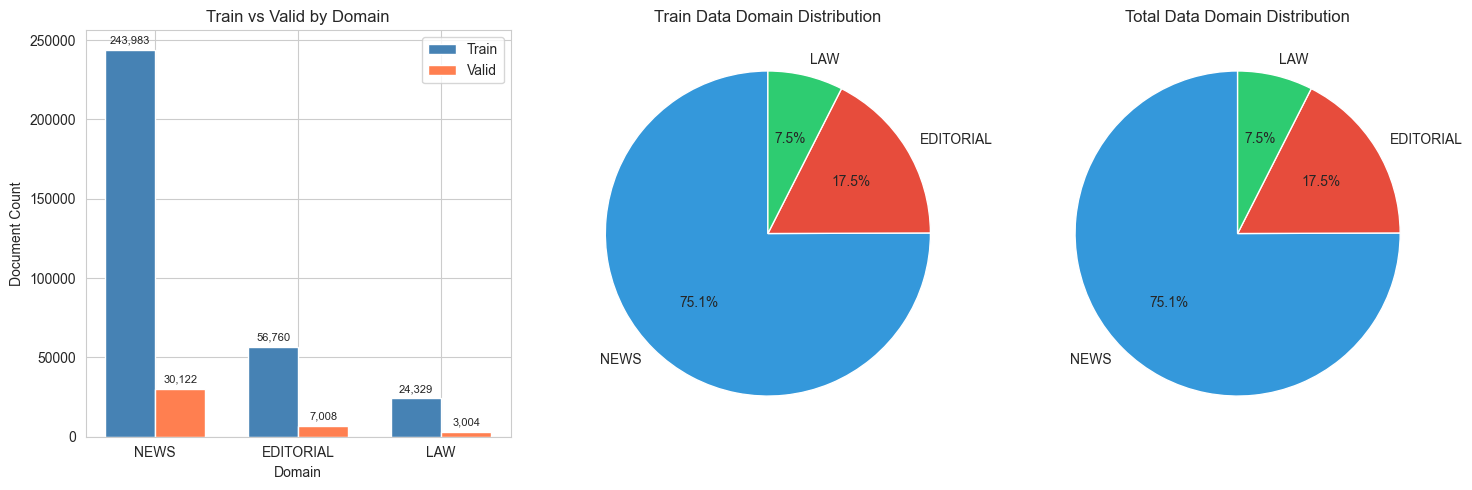


[분석 포인트]
- NEWS 데이터가 전체의 약 75%로 가장 많음
- LAW 데이터가 가장 적음 (약 7.5%)
- 학습 시 도메인 불균형 처리 필요


In [12]:
# 도메인별 데이터 분포 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. 도메인별 문서 수 (Train vs Valid)
domains = ['NEWS', 'EDITORIAL', 'LAW']
train_counts = [pivot_df.loc[d, 'TRAIN'] for d in domains]
valid_counts = [pivot_df.loc[d, 'VALID'] for d in domains]

x = np.arange(len(domains))
width = 0.35

bars1 = axes[0].bar(x - width/2, train_counts, width, label='Train', color='steelblue')
bars2 = axes[0].bar(x + width/2, valid_counts, width, label='Valid', color='coral')
axes[0].set_xlabel('Domain')
axes[0].set_ylabel('Document Count')
axes[0].set_title('Train vs Valid by Domain')
axes[0].set_xticks(x)
axes[0].set_xticklabels(domains)
axes[0].legend()
axes[0].ticklabel_format(style='plain', axis='y')

# 막대 위에 숫자 표시
for bar in bars1:
    height = bar.get_height()
    axes[0].annotate(f'{int(height):,}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    axes[0].annotate(f'{int(height):,}',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 3), textcoords="offset points",
                     ha='center', va='bottom', fontsize=8)

# 2. Train 데이터 도메인 비율 (파이 차트)
colors = ['#3498db', '#e74c3c', '#2ecc71']
axes[1].pie(train_counts, labels=domains, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Train Data Domain Distribution')

# 3. 전체 데이터 도메인 비율 (파이 차트)
total_counts = [t + v for t, v in zip(train_counts, valid_counts)]
axes[2].pie(total_counts, labels=domains, autopct='%1.1f%%', colors=colors, startangle=90)
axes[2].set_title('Total Data Domain Distribution')

plt.tight_layout()
plt.show()

print("\n[분석 포인트]")
print("- NEWS 데이터가 전체의 약 75%로 가장 많음")
print("- LAW 데이터가 가장 적음 (약 7.5%)")
print("- 학습 시 도메인 불균형 처리 필요")

## 6. 텍스트 길이 분석

In [13]:
# 텍스트 추출 및 길이 계산 함수
def extract_full_text(doc):
    """문서에서 전체 텍스트를 추출"""
    sentences = []
    if 'text' in doc:
        for paragraph in doc['text']:
            for sent_obj in paragraph:
                if isinstance(sent_obj, dict) and 'sentence' in sent_obj:
                    sentences.append(sent_obj['sentence'])
    return ' '.join(sentences)

def get_abstractive_summary(doc):
    """생성 요약 추출"""
    return doc.get('abstractive', '')

def get_extractive_summary(doc):
    """추출 요약 추출 (문장 인덱스 기반)"""
    if 'extractive' not in doc:
        return ''
    
    extractive_indices = doc['extractive']
    sentences = []
    if 'text' in doc:
        all_sentences = []
        for paragraph in doc['text']:
            for sent_obj in paragraph:
                if isinstance(sent_obj, dict) and 'sentence' in sent_obj:
                    all_sentences.append(sent_obj['sentence'])
        
        for idx in extractive_indices:
            if idx < len(all_sentences):
                sentences.append(all_sentences[idx])
    
    return ' '.join(sentences)

# Train 데이터에서 텍스트 길이 분석
print("텍스트 길이 분석 중... (시간이 걸릴 수 있습니다)")

length_data = []

for domain in ['news', 'editorial', 'law']:
    docs = all_data['train'][domain]['documents']
    # 샘플링 (너무 많으면 시간이 오래 걸림)
    sample_size = min(10000, len(docs))
    sampled_docs = np.random.choice(docs, sample_size, replace=False)
    
    for doc in sampled_docs:
        full_text = extract_full_text(doc)
        abstractive = get_abstractive_summary(doc)
        
        length_data.append({
            'domain': domain.upper(),
            'text_length': len(full_text),
            'text_word_count': len(full_text.split()),
            'abstractive_length': len(abstractive),
            'char_count': int(doc.get('char_count', 0)) if doc.get('char_count') else 0,
            'size': doc.get('size', 'unknown')
        })

length_df = pd.DataFrame(length_data)
print("✓ 텍스트 길이 분석 완료!")

텍스트 길이 분석 중... (시간이 걸릴 수 있습니다)
✓ 텍스트 길이 분석 완료!


In [14]:
# 도메인별 텍스트 길이 통계
print("=" * 60)
print("도메인별 텍스트 길이 통계")
print("=" * 60)

stats_df = length_df.groupby('domain').agg({
    'text_length': ['mean', 'std', 'min', 'max', 'median'],
    'abstractive_length': ['mean', 'std', 'min', 'max', 'median']
}).round(1)

print("\n[원문 텍스트 길이 (문자 수)]")
print(stats_df['text_length'].to_string())

print("\n[생성 요약 길이 (문자 수)]")
print(stats_df['abstractive_length'].to_string())

# 압축률 계산
print("\n[평균 압축률 (요약/원문)]")
for domain in ['NEWS', 'EDITORIAL', 'LAW']:
    domain_data = length_df[length_df['domain'] == domain]
    avg_text = domain_data['text_length'].mean()
    avg_summary = domain_data['abstractive_length'].mean()
    compression = (avg_summary / avg_text * 100) if avg_text > 0 else 0
    print(f"  {domain}: {compression:.1f}%")

도메인별 텍스트 길이 통계

[원문 텍스트 길이 (문자 수)]
             mean    std  min   max  median
domain                                     
EDITORIAL  1170.2  242.3  177  1933  1134.0
LAW         667.4  443.9   81  3769   541.0
NEWS       1008.7  292.4  550  1966   936.0

[생성 요약 길이 (문자 수)]
           mean  std  min  max  median
domain                                
EDITORIAL   1.0  0.0    1    1     1.0
LAW         1.0  0.0    1    1     1.0
NEWS        1.0  0.0    1    1     1.0

[평균 압축률 (요약/원문)]
  NEWS: 0.1%
  EDITORIAL: 0.1%
  LAW: 0.1%


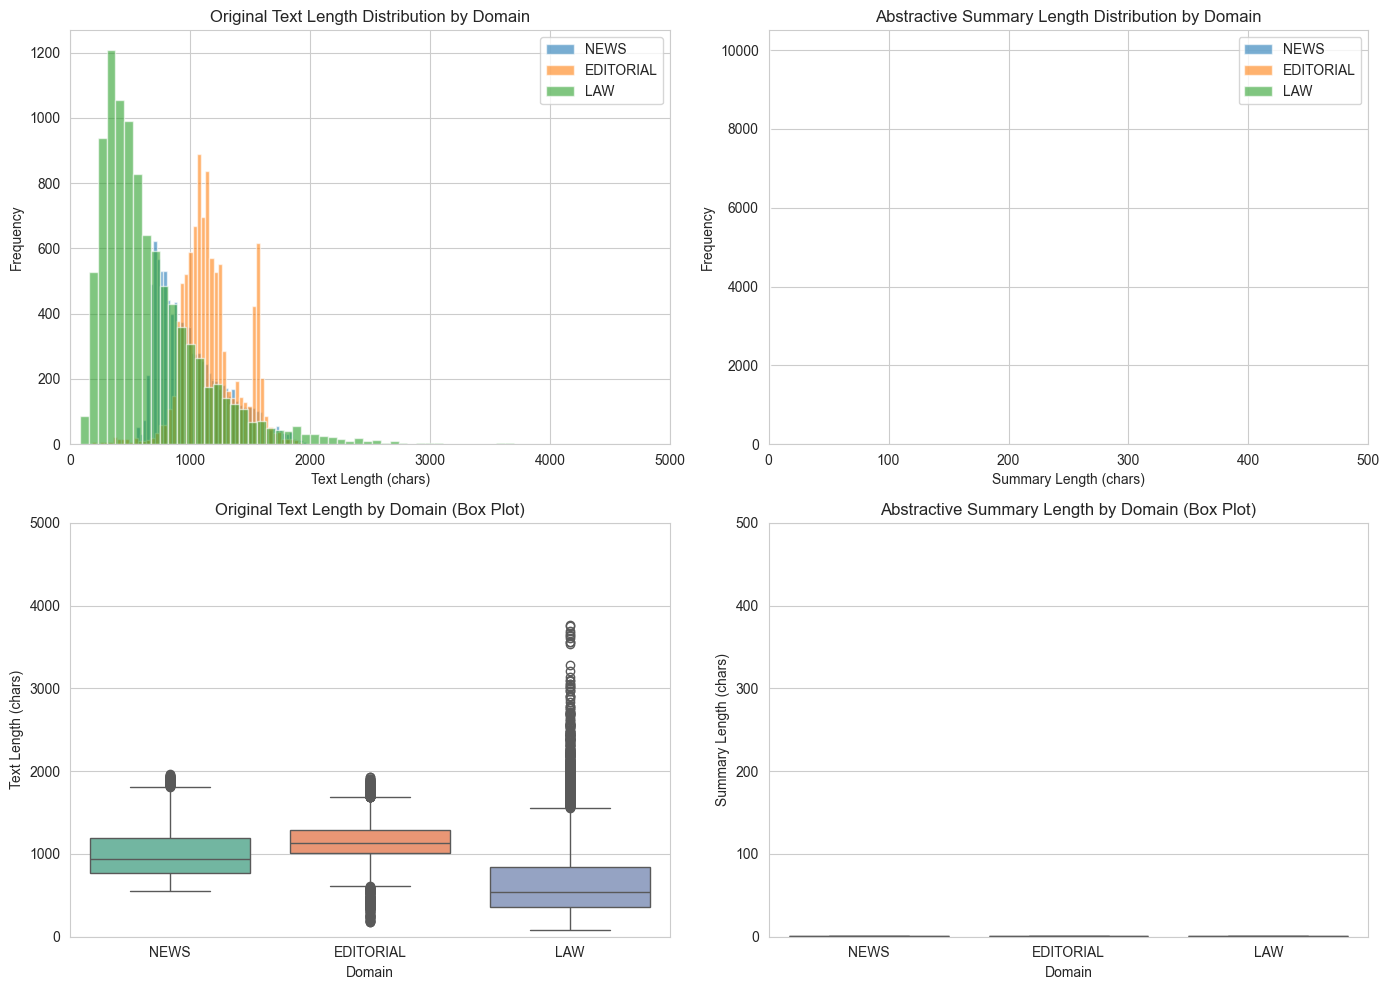


[분석 포인트]
- LAW 도메인이 원문 길이가 가장 짧고 변동이 적음
- EDITORIAL이 원문과 요약 모두 가장 긴 경향
- NEWS는 길이 분포가 넓어 다양한 기사 유형 포함


In [15]:
# 텍스트 길이 분포 시각화
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 도메인별 원문 텍스트 길이 분포 (히스토그램)
for domain in ['NEWS', 'EDITORIAL', 'LAW']:
    domain_data = length_df[length_df['domain'] == domain]['text_length']
    axes[0, 0].hist(domain_data, bins=50, alpha=0.6, label=domain)
axes[0, 0].set_xlabel('Text Length (chars)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Original Text Length Distribution by Domain')
axes[0, 0].legend()
axes[0, 0].set_xlim(0, 5000)  # 극단값 제외

# 2. 도메인별 요약 길이 분포 (히스토그램)
for domain in ['NEWS', 'EDITORIAL', 'LAW']:
    domain_data = length_df[length_df['domain'] == domain]['abstractive_length']
    axes[0, 1].hist(domain_data, bins=50, alpha=0.6, label=domain)
axes[0, 1].set_xlabel('Summary Length (chars)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Abstractive Summary Length Distribution by Domain')
axes[0, 1].legend()
axes[0, 1].set_xlim(0, 500)

# 3. 도메인별 원문 길이 박스플롯
sns.boxplot(data=length_df, x='domain', y='text_length', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_xlabel('Domain')
axes[1, 0].set_ylabel('Text Length (chars)')
axes[1, 0].set_title('Original Text Length by Domain (Box Plot)')
axes[1, 0].set_ylim(0, 5000)

# 4. 도메인별 요약 길이 박스플롯
sns.boxplot(data=length_df, x='domain', y='abstractive_length', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_xlabel('Domain')
axes[1, 1].set_ylabel('Summary Length (chars)')
axes[1, 1].set_title('Abstractive Summary Length by Domain (Box Plot)')
axes[1, 1].set_ylim(0, 500)

plt.tight_layout()
plt.show()

print("\n[분석 포인트]")
print("- LAW 도메인이 원문 길이가 가장 짧고 변동이 적음")
print("- EDITORIAL이 원문과 요약 모두 가장 긴 경향")
print("- NEWS는 길이 분포가 넓어 다양한 기사 유형 포함")

## 7. 카테고리 분석

In [ ]:
# 도메인별 카테고리 분포 분석
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, domain in enumerate(['news', 'editorial', 'law']):
    docs = all_data['train'][domain]['documents']
    categories = [doc.get('category', 'Unknown') for doc in docs]
    category_counts = pd.Series(categories).value_counts().head(10)
    
    bars = axes[idx].barh(category_counts.index, category_counts.values, color=colors[idx])
    axes[idx].set_xlabel('Document Count')
    axes[idx].set_title(f'{domain.upper()} - Top 10 Categories')
    axes[idx].invert_yaxis()
    
    # 숫자 표시
    for bar, count in zip(bars, category_counts.values):
        axes[idx].text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, 
                      f'{count:,}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# 각 도메인별 카테고리 수
print("\n[도메인별 고유 카테고리 수]")
for domain in ['news', 'editorial', 'law']:
    docs = all_data['train'][domain]['documents']
    categories = set(doc.get('category', 'Unknown') for doc in docs)
    print(f"  {domain.upper()}: {len(categories)}개")

## 8. 문서 크기(size) 분포 분석

In [ ]:
# 문서 크기(size) 분포 분석
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 전체 size 분포
size_data = []
for domain in ['news', 'editorial', 'law']:
    docs = all_data['train'][domain]['documents']
    for doc in docs:
        size_data.append({
            'domain': domain.upper(),
            'size': doc.get('size', 'unknown')
        })

size_df = pd.DataFrame(size_data)

# 1. 도메인별 size 분포 (Stacked Bar)
size_order = ['small', 'medium', 'large']
size_pivot = pd.crosstab(size_df['domain'], size_df['size'])
# size_order에 있는 열만 선택 (없는 경우 대비)
available_sizes = [s for s in size_order if s in size_pivot.columns]
size_pivot = size_pivot[available_sizes]

size_pivot.plot(kind='bar', stacked=True, ax=axes[0], color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_xlabel('Domain')
axes[0].set_ylabel('Document Count')
axes[0].set_title('Document Size Distribution by Domain')
axes[0].legend(title='Size')
axes[0].tick_params(axis='x', rotation=0)

# 2. 전체 size 비율 (파이 차트)
total_size_counts = size_df['size'].value_counts()
# size_order 순서로 정렬
total_size_counts = total_size_counts.reindex([s for s in size_order if s in total_size_counts.index])
axes[1].pie(total_size_counts.values, labels=total_size_counts.index, 
            autopct='%1.1f%%', colors=['#2ecc71', '#f39c12', '#e74c3c'], startangle=90)
axes[1].set_title('Overall Document Size Distribution')

plt.tight_layout()
plt.show()

# size별 평균 문자 수
print("\n[Size별 평균 문자 수]")
size_char_data = []
for domain in ['news', 'editorial', 'law']:
    docs = all_data['train'][domain]['documents']
    for doc in docs:
        char_count = doc.get('char_count', 0)
        if isinstance(char_count, str):
            char_count = int(char_count) if char_count.isdigit() else 0
        size_char_data.append({
            'size': doc.get('size', 'unknown'),
            'char_count': char_count
        })

size_char_df = pd.DataFrame(size_char_data)
print(size_char_df.groupby('size')['char_count'].agg(['mean', 'min', 'max']).round(0).to_string())

## 9. 요약 품질 점수 분석

In [ ]:
# 요약 품질 점수 분석 (document_quality_scores 또는 abstractive_quality_scores)
quality_data = []

for domain in ['news', 'editorial', 'law']:
    docs = all_data['train'][domain]['documents']
    
    for doc in docs:
        # document_quality_scores 체크
        doc_quality = doc.get('document_quality_scores', {})
        abs_quality = doc.get('abstractive_quality_scores', {})
        
        if doc_quality or abs_quality:
            quality_entry = {'domain': domain.upper()}
            
            # document_quality_scores
            for key in ['readable', 'accurate', 'informative', 'trustworthy']:
                quality_entry[f'doc_{key}'] = doc_quality.get(key, np.nan)
            
            # abstractive_quality_scores
            for key in ['readable', 'accurate', 'informative', 'trustworthy']:
                quality_entry[f'abs_{key}'] = abs_quality.get(key, np.nan)
            
            quality_data.append(quality_entry)

if quality_data:
    quality_df = pd.DataFrame(quality_data)
    
    # 도메인별 품질 점수 평균
    print("=" * 60)
    print("요약 품질 점수 분석")
    print("=" * 60)
    
    # Document Quality Scores
    doc_cols = [c for c in quality_df.columns if c.startswith('doc_')]
    if any(quality_df[doc_cols].notna().any()):
        print("\n[문서 품질 점수 (Document Quality Scores)]")
        doc_quality_mean = quality_df.groupby('domain')[doc_cols].mean().round(2)
        doc_quality_mean.columns = [c.replace('doc_', '') for c in doc_quality_mean.columns]
        print(doc_quality_mean.to_string())
    
    # Abstractive Quality Scores
    abs_cols = [c for c in quality_df.columns if c.startswith('abs_')]
    if any(quality_df[abs_cols].notna().any()):
        print("\n[요약 품질 점수 (Abstractive Quality Scores)]")
        abs_quality_mean = quality_df.groupby('domain')[abs_cols].mean().round(2)
        abs_quality_mean.columns = [c.replace('abs_', '') for c in abs_quality_mean.columns]
        print(abs_quality_mean.to_string())
    
    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Document Quality 히트맵
    if any(quality_df[doc_cols].notna().any()):
        doc_heatmap_data = quality_df.groupby('domain')[doc_cols].mean()
        doc_heatmap_data.columns = [c.replace('doc_', '') for c in doc_heatmap_data.columns]
        sns.heatmap(doc_heatmap_data, annot=True, cmap='YlGnBu', ax=axes[0], vmin=1, vmax=5, fmt='.2f')
        axes[0].set_title('Document Quality Scores by Domain')
    
    # Abstractive Quality 히트맵
    if any(quality_df[abs_cols].notna().any()):
        abs_heatmap_data = quality_df.groupby('domain')[abs_cols].mean()
        abs_heatmap_data.columns = [c.replace('abs_', '') for c in abs_heatmap_data.columns]
        sns.heatmap(abs_heatmap_data, annot=True, cmap='YlOrRd', ax=axes[1], vmin=1, vmax=5, fmt='.2f')
        axes[1].set_title('Abstractive Summary Quality Scores by Domain')
    
    plt.tight_layout()
    plt.show()
else:
    print("품질 점수 데이터가 없습니다.")

## 10. 샘플 문서 확인

In [ ]:
# 각 도메인에서 샘플 문서 확인
def display_sample_document(doc, domain):
    """샘플 문서를 보기 좋게 출력"""
    print(f"\n{'='*60}")
    print(f"[{domain.upper()} 샘플 문서]")
    print(f"{'='*60}")
    print(f"ID: {doc.get('id', 'N/A')}")
    print(f"제목: {doc.get('title', 'N/A')}")
    print(f"카테고리: {doc.get('category', 'N/A')}")
    print(f"크기: {doc.get('size', 'N/A')}")
    print(f"문자 수: {doc.get('char_count', 'N/A')}")
    
    # 원문 텍스트
    full_text = extract_full_text(doc)
    print(f"\n[원문] ({len(full_text)}자)")
    print("-" * 40)
    print(full_text[:500] + "..." if len(full_text) > 500 else full_text)
    
    # 생성 요약
    abstractive = doc.get('abstractive', '')
    if abstractive:
        print(f"\n[생성 요약 (Abstractive)] ({len(abstractive)}자)")
        print("-" * 40)
        print(abstractive)
    
    # 추출 요약 인덱스
    extractive = doc.get('extractive', [])
    if extractive:
        print(f"\n[추출 요약 인덱스 (Extractive)]")
        print("-" * 40)
        print(f"선택된 문장 인덱스: {extractive}")
        
        # 추출 요약 문장 출력
        extractive_text = get_extractive_summary(doc)
        print(f"\n[추출된 문장들]")
        print(extractive_text[:300] + "..." if len(extractive_text) > 300 else extractive_text)

# 각 도메인에서 1개씩 샘플 출력
for domain in ['news', 'editorial', 'law']:
    # medium 크기 문서 중에서 선택 (너무 짧거나 길지 않은)
    docs = all_data['train'][domain]['documents']
    medium_docs = [d for d in docs if d.get('size') == 'medium']
    if medium_docs:
        sample_doc = np.random.choice(medium_docs)
    else:
        sample_doc = docs[0]
    
    display_sample_document(sample_doc, domain)

## 11. EDA 요약 및 학습 권장사항

In [ ]:
# EDA 최종 요약
print("=" * 70)
print("                      EDA 최종 요약")
print("=" * 70)

print("\n[1. 데이터 규모]")
print(f"   - 전체 문서 수: {pivot_df['Total'].sum():,}개")
print(f"   - Train: {pivot_df['TRAIN'].sum():,}개 / Valid: {pivot_df['VALID'].sum():,}개")
print(f"   - Train:Valid 비율 = 약 89:11")

print("\n[2. 도메인 분포 (불균형)]")
for domain in ['NEWS', 'EDITORIAL', 'LAW']:
    total = pivot_df.loc[domain, 'Total']
    ratio = total / pivot_df['Total'].sum() * 100
    print(f"   - {domain}: {total:,}개 ({ratio:.1f}%)")

print("\n[3. 텍스트 길이 특성]")
for domain in ['NEWS', 'EDITORIAL', 'LAW']:
    domain_data = length_df[length_df['domain'] == domain]
    avg_text = domain_data['text_length'].mean()
    avg_summary = domain_data['abstractive_length'].mean()
    print(f"   - {domain}: 원문 평균 {avg_text:.0f}자, 요약 평균 {avg_summary:.0f}자")

print("\n[4. 학습 권장사항]")
print("""
   1) 데이터 통합: 3개 도메인을 하나의 DataFrame으로 통합
   2) 불균형 처리: 
      - 옵션 A: NEWS 언더샘플링 (각 도메인 ~25,000개로 맞춤)
      - 옵션 B: 도메인별 가중치 적용 (Loss에 가중치)
      - 옵션 C: 전체 사용 (도메인 라벨 추가)
   3) 텍스트 전처리:
      - max_length 설정: 원문 1024~2048 토큰, 요약 128~256 토큰
      - 토크나이저: KoBART 또는 mT5 권장
   4) 요약 타입:
      - Abstractive (생성 요약) 학습 권장 (모든 문서에 존재)
      - Extractive는 문장 선택 문제로 별도 모델링 가능
""")

print("=" * 70)
print("                   EDA 완료! 다음 단계로 진행하세요.")
print("=" * 70)